In [1]:
import sys
import os
sys.path.append(os.path.abspath("src"))

In [2]:
from src.limpieza_datos import ejecutar_limpieza
from src.conexiones_grafo import ejecutar_conexiones
from src.grafo import construir_grafo_desde_rutas
from src.dijkstra import buscar_hospital_adecuado
from src.prim import ejecutar_prim
from src.kdtree import construir_kdtree_hospitales
from src.geoespacial import preparar_candidatos_geoespaciales
from src.MaxHeap import construir_heap_emergencias
from src.visualizaciones import visualizar_ruta_en_mapa_si
from src.visualizaciones import (
    visualizar_ruta_dijkstra,
    visualizar_hospitales_cercanos,
    imprimir_resultado_dijkstra,
    imprimir_resultado_prim,
    visualizar_grafo_rutas_hospitalarias,
    visualizar_grafo_hospitales_completo,
    visualizar_mst_geografico,
    visualizar_grafo_trafico_por_hora,
)

In [3]:
#Limpieza de datos:
datos = ejecutar_limpieza()

hospitales = datos["hospitales"]
capacidades = datos["capacidades"]
emergencias = datos["emergencias"]

In [4]:
# CONSTRUCCIÓN DE GRAFOS

rutas_completas = ejecutar_conexiones(
    k_viales=50,
)
grafo = construir_grafo_desde_rutas(
    rutas_completas
)

# Grafo visual más ligero
rutas_visual = ejecutar_conexiones(
    k_viales=8,
)

grafo_visual = construir_grafo_desde_rutas(
    rutas_visual
)



In [5]:
#Heap para determinar la prioridad de las emergencias

heap_emergencias = construir_heap_emergencias(
    emergencias
)
emergencia = heap_emergencias.extraer_maximo()

print("Emergencia seleccionada por prioridad:")

print(emergencia)

Emergencia seleccionada por prioridad:
id_emergencia                         E01
id_nodo_origen                       V8_0
nombre_origen             Avenida Jalisco
lat                              19.39743
lon                            -99.190014
especialidad_requerida          urgencias
prioridad                            ROJO
Name: 0, dtype: object


In [6]:
#KD Tree
    #Encuentra hospitales cercanos 

radio_km = 10
kdtree = construir_kdtree_hospitales(hospitales)

hospitales_cercanos, capacidades_filtradas = preparar_candidatos_geoespaciales(
    hospitales,
    capacidades,
    emergencia,
    radio_km=radio_km,
)

In [7]:
# Dijkstra con el tráfico por hora

hora_emergencia = 18

resultado_dijkstra = buscar_hospital_adecuado(
    grafo,
    emergencia,
    capacidades_filtradas,
    hora=hora_emergencia,
)

In [8]:
resultado_prim = ejecutar_prim(hospitales)


RESULTADO DIJKSTRA:
Hospital: Hospital Regional "Lic. Adolfo López Mateos"
Especialidad: urgencias
Camas disponibles: 9
Costo de ruta: 8.033
Ruta:
 -> V8_0
 -> V20_1
 -> V19_0
 -> V74_2
 -> V4_0
 -> V4_1
 -> way/1365216619


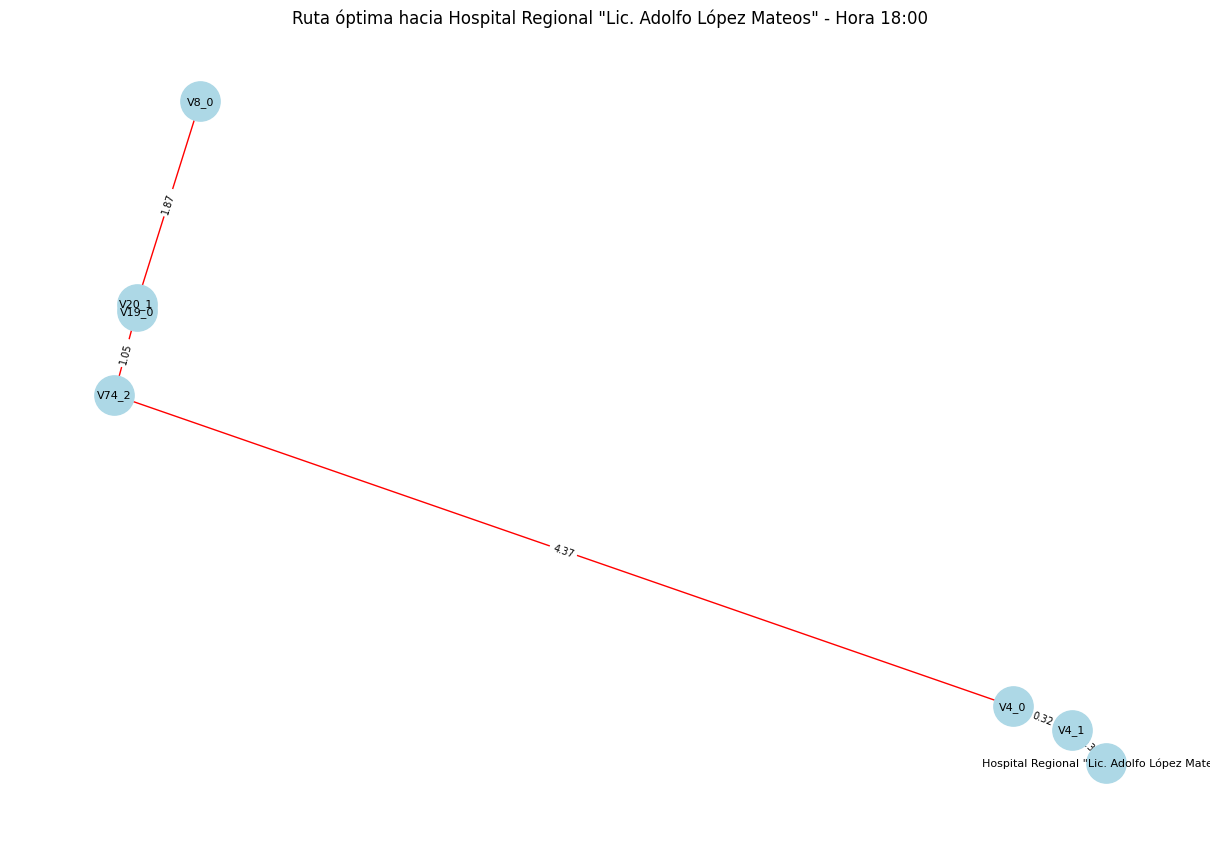

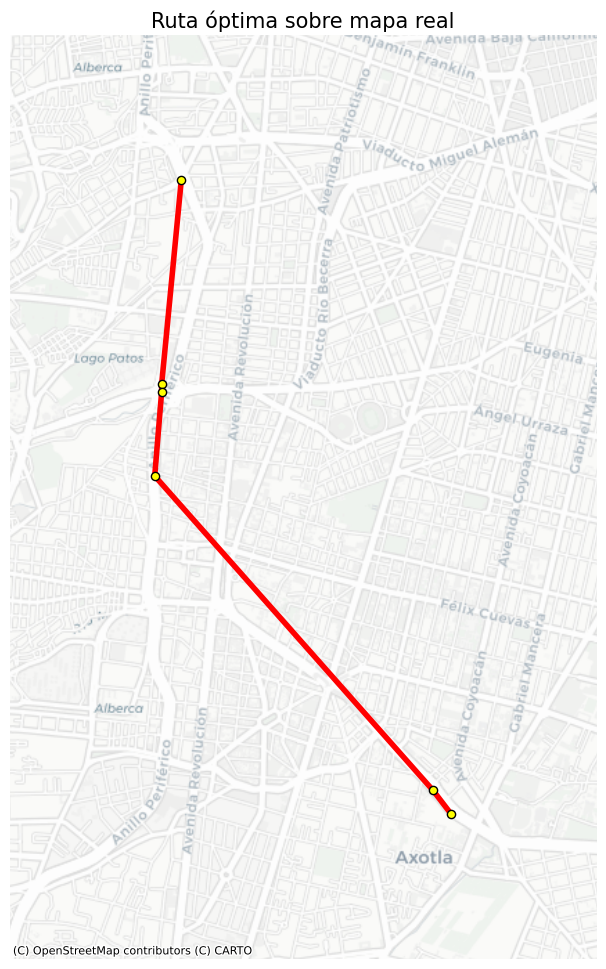

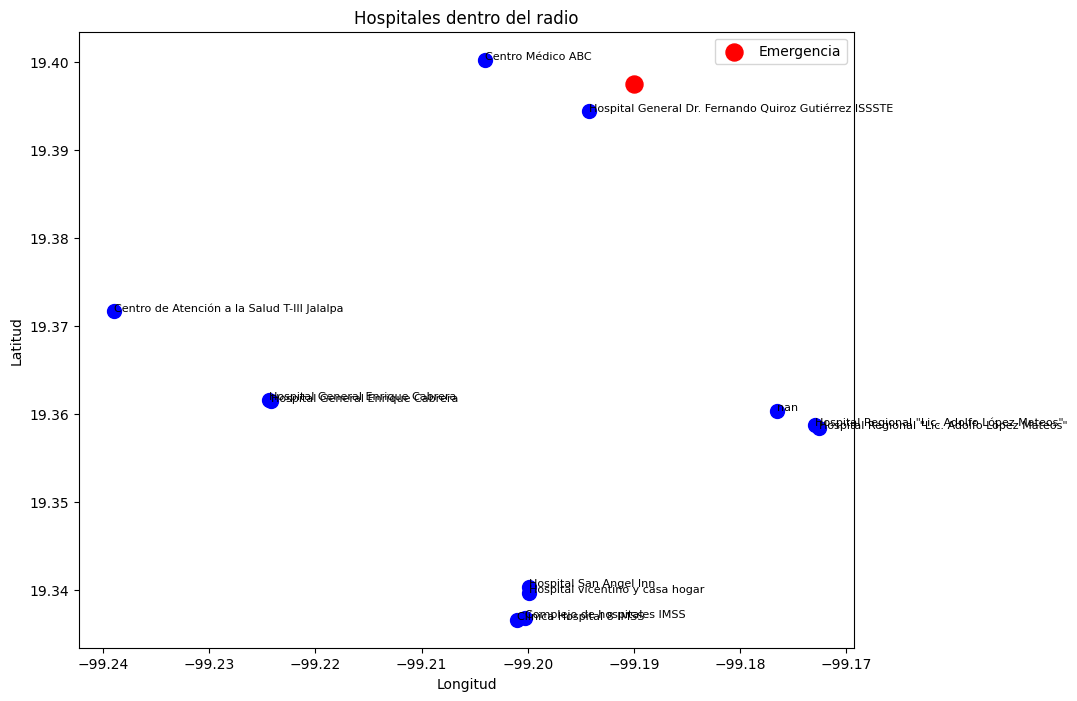


RESULTADO PRIM:
Costo total MST: 20.976

Aristas MST:
               origen          destino  costo
0   relation/11632168   node/739035810  0.077
1   relation/11632168  node/4403446355  0.321
2     node/4403446355   node/319436637  0.075
3       way/883666969     way/27804337  1.213
4      way/1364990384    way/883666969  4.218
5     node/9768668045  node/2324519237  0.025
6      node/319436637  node/9768668045  3.463
7      node/319436637   way/1364990384  3.306
8      way/1364990384   way/1365266055  0.409
9     node/2324519237    way/986068924  1.897
10     way/1365266055   way/1365216619  0.058
11      way/986068924  node/3977351148  5.914


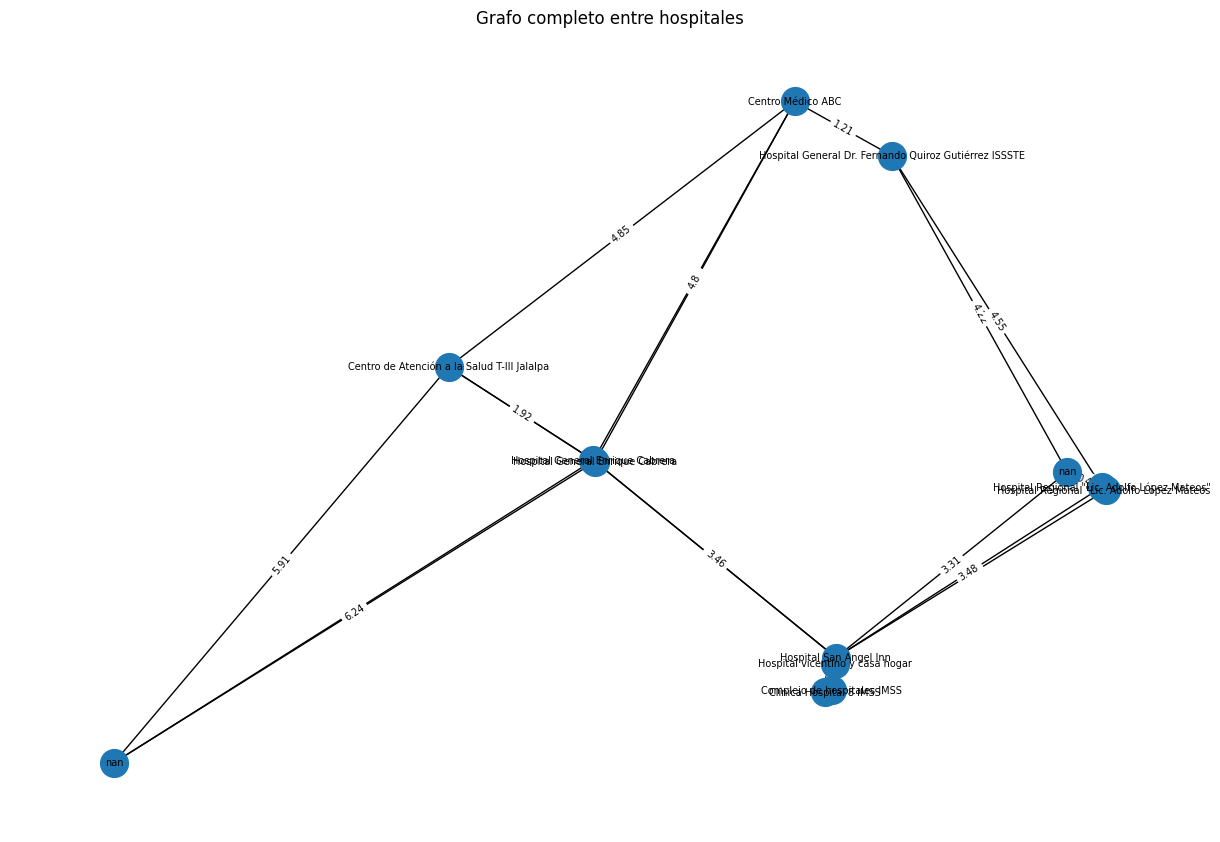

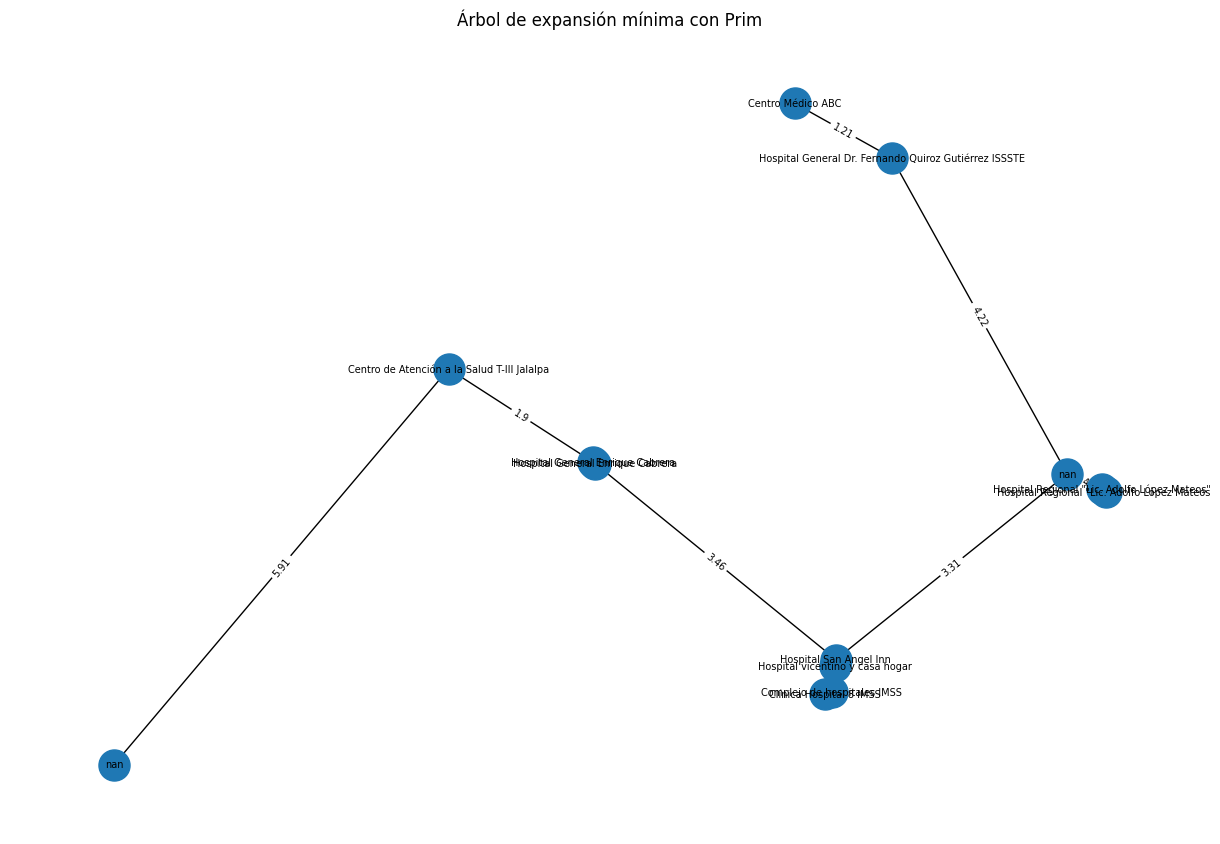

In [9]:
# Resultados e impresión de grafos

imprimir_resultado_dijkstra(resultado_dijkstra)

visualizar_ruta_dijkstra(
    resultado_dijkstra,
    grafo=grafo,
    nodos_viales=datos["nodos_viales"],
    hospitales=hospitales,
    hora=hora_emergencia,
)

visualizar_ruta_en_mapa_si(
    resultado_dijkstra,
    nodos_viales=datos["nodos_viales"],
    hospitales=hospitales
)

visualizar_hospitales_cercanos(
    hospitales_cercanos,
    emergencia,
)

imprimir_resultado_prim(
    resultado_prim
)

visualizar_grafo_hospitales_completo(
    resultado_prim["grafo_hospitales"],
    hospitales,
)

visualizar_mst_geografico(
    resultado_prim["padre"],
    resultado_prim["llave"],
    hospitales,
)

In [10]:
# Se elimina la emergencia ya atendida y se busca atender una nueva
emergencias_pendientes = emergencias[emergencias["id_emergencia"] != emergencia["id_emergencia"]].copy()

#se reconstruye el heap con las emergencias pendientes
heap_emergencias = construir_heap_emergencias(emergencias_pendientes)

# Tomar siguiente emergencia más urgente
emergencia = heap_emergencias.extraer_maximo()
print("Siguiente emergencia seleccionada:")
print(emergencia)


Siguiente emergencia seleccionada:
id_emergencia                                           E04
id_nodo_origen                                        V36_1
nombre_origen             Carretera México - Toluca (Cuota)
lat                                               19.373793
lon                                              -99.263271
especialidad_requerida                            urgencias
prioridad                                              ROJO
Name: 3, dtype: object



RESULTADO DIJKSTRA:
Hospital: Hospital Regional "Lic. Adolfo López Mateos"
Especialidad: urgencias
Camas disponibles: 9
Costo de ruta: 17.671
Ruta:
 -> V36_1
 -> V48_2
 -> V7_0
 -> V20_2
 -> V74_2
 -> V4_0
 -> V4_1
 -> way/1365216619


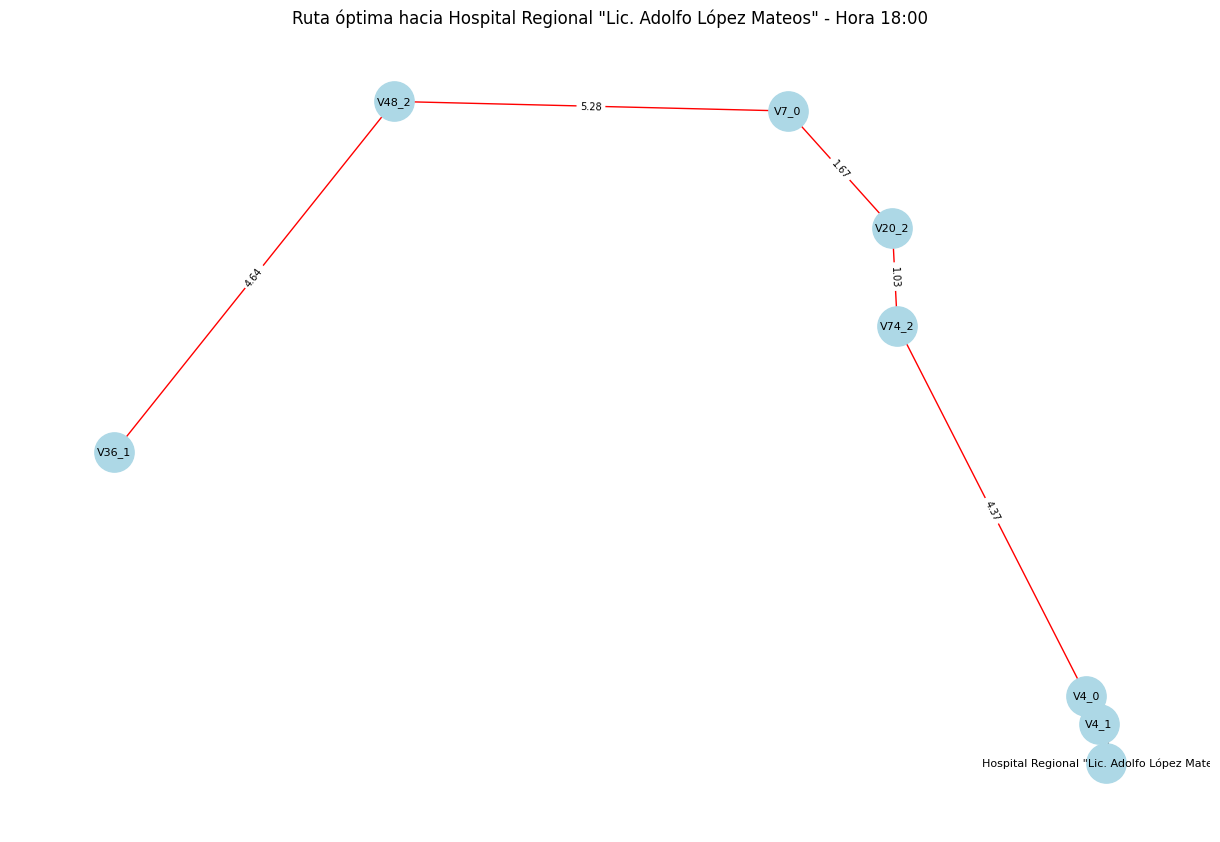

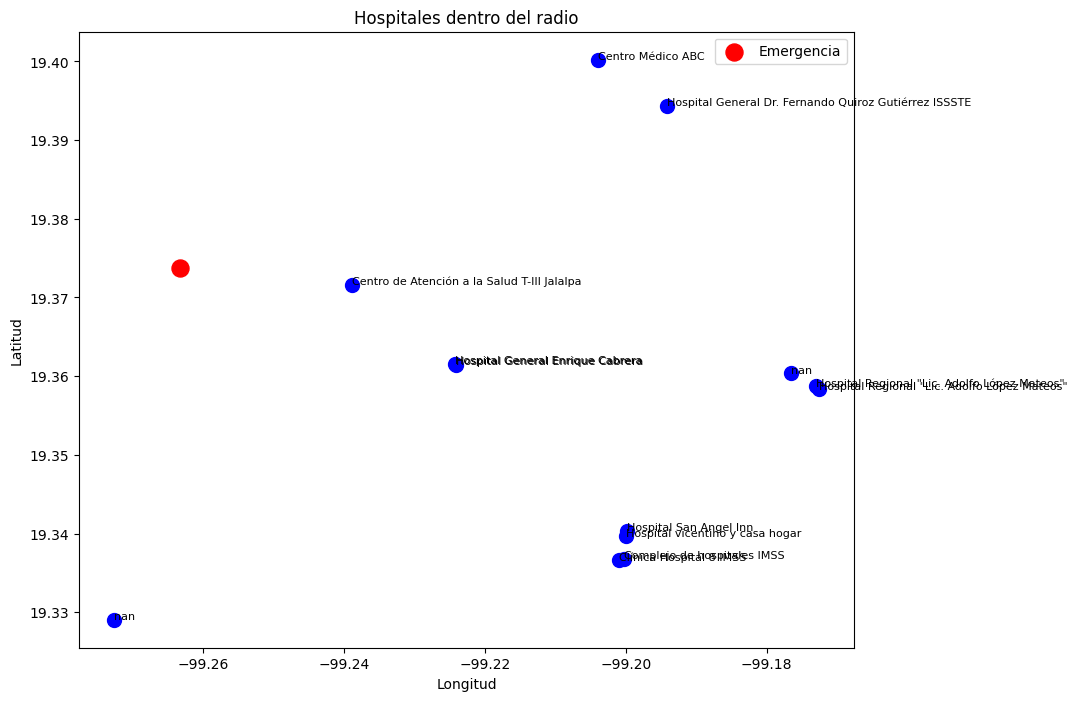

In [11]:
hospitales_cercanos, capacidades_filtradas = preparar_candidatos_geoespaciales(
    hospitales,
    capacidades,
    emergencia,
    radio_km=radio_km,
)
resultado_dijkstra = buscar_hospital_adecuado(
    grafo,
    emergencia,
    capacidades_filtradas,
    hora=hora_emergencia,
)

radio_km = 10
kdtree = construir_kdtree_hospitales(hospitales)

hospitales_cercanos, capacidades_filtradas = preparar_candidatos_geoespaciales(
    hospitales,
    capacidades,
    emergencia,
    radio_km=radio_km,
)

imprimir_resultado_dijkstra(resultado_dijkstra)

visualizar_ruta_dijkstra(
    resultado_dijkstra,
    grafo=grafo,
    nodos_viales=datos["nodos_viales"],
    hospitales=hospitales,
    hora=hora_emergencia,
)

visualizar_hospitales_cercanos(
    hospitales_cercanos,
    emergencia,
)

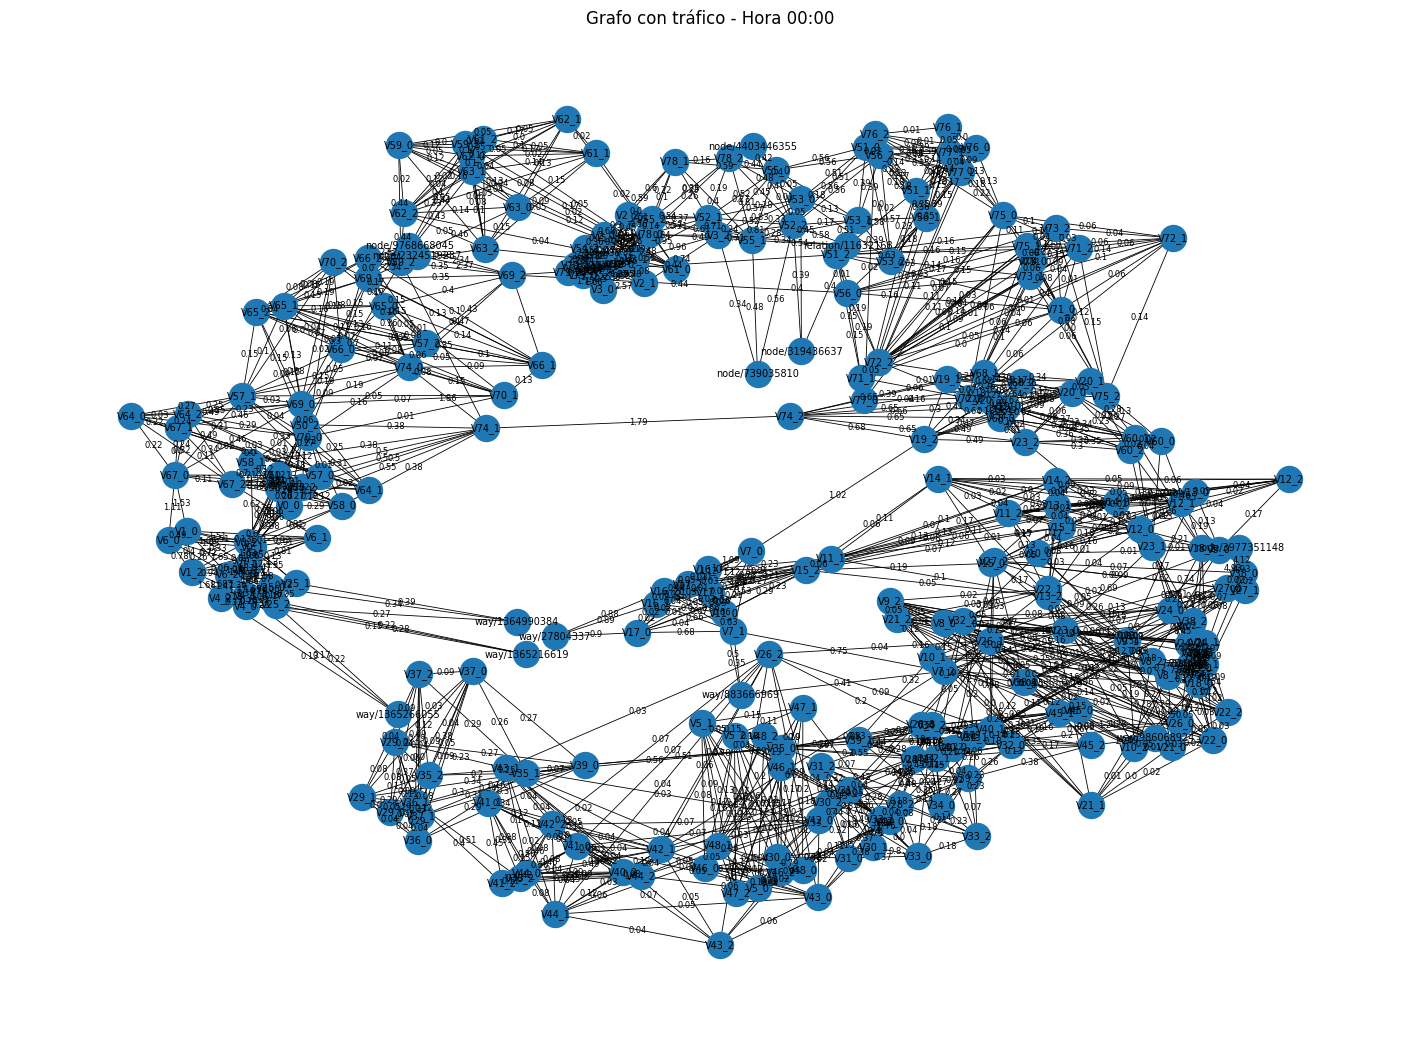

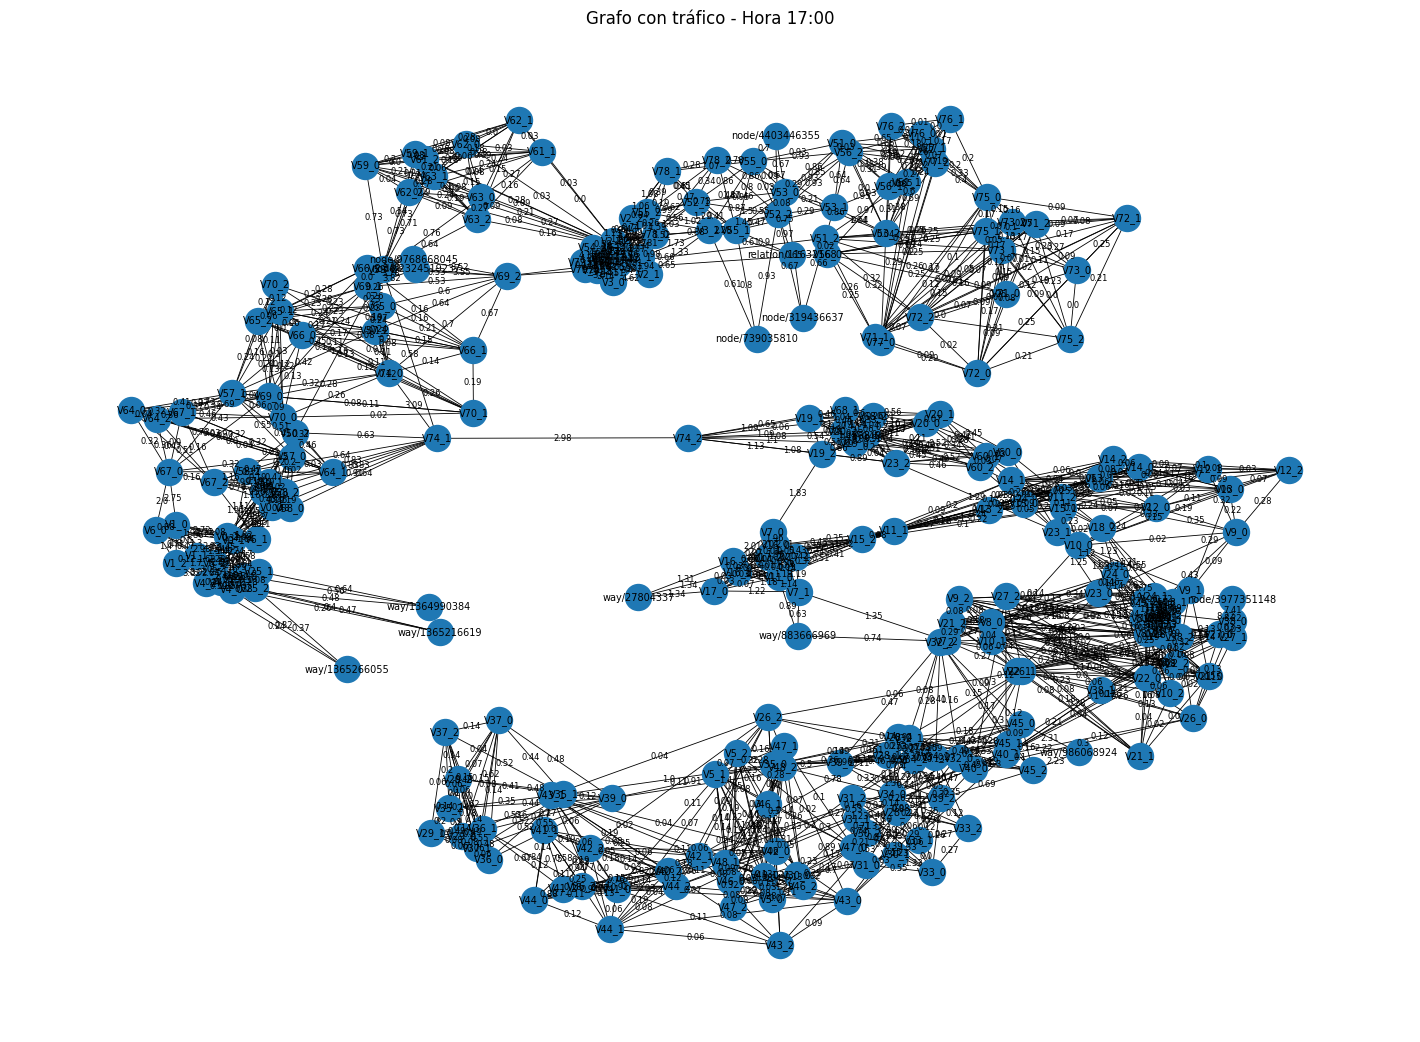

In [12]:
# visualización del trafico por hora

visualizar_grafo_trafico_por_hora(
    grafo_visual,
    hora=0,
    mostrar_pesos=True,
)

visualizar_grafo_trafico_por_hora(
    grafo_visual,
    hora=17,
    mostrar_pesos=True,
)
